# Perbandingan Ringkas Full 180 Detik vs 3 Segment — DACM RR/HR

Notebook ini dibuat agar output tidak terlalu penuh. Proses radar tetap dijalankan, tetapi output yang ditampilkan hanya:

1. tabel akhir perbandingan Full 180 detik vs 3 segment,
2. grafik akhir untuk RR,
3. grafik akhir untuk HR,
4. kesimpulan metode yang lebih dekat ke ground truth jika ground truth diisi.

Metode yang dibandingkan:

- RR: Frequency Domain / FFT dari sinyal RR hasil DACM + filter 0,10–0,50 Hz.
- HR: Time Domain / peak detection dari sinyal HR hasil DACM + filter 0,80–2,00 Hz.


In [52]:
# ============================================================
# 1) ISI GROUND TRUTH DI SINI
# ============================================================
# Kalau belum punya ground truth, biarkan None.
# Setelah ground truth diisi, jalankan ulang mulai dari cell ini sampai cell hasil akhir.

GROUND_TRUTH = {
    "Subject 1": {"RR": None, "HR": None},
    "Subject 2": {"RR": None, "HR": None},
}

print("Ground truth saat ini:")
GROUND_TRUTH


Ground truth saat ini:


{'Subject 1': {'RR': None, 'HR': None}, 'Subject 2': {'RR': None, 'HR': None}}

## 2) Proses radar, DACM, dan filtering

Jalankan cell di bawah ini. Output sengaja disembunyikan agar notebook tetap ringan. Setelah selesai, langsung lihat cell hasil akhir.

In [53]:
%%capture
# Semua proses radar dijalankan diam-diam di cell ini agar output notebook tetap ringkas.

import os
import gc
from pathlib import Path, PureWindowsPath

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from scipy.ndimage import gaussian_filter1d, gaussian_filter, maximum_filter
from scipy.signal import find_peaks, butter, sosfiltfilt, sosfreqz, detrend as sp_detrend
from IPython.display import display

np.set_printoptions(precision=4, suppress=True)

from IPython.display import Markdown



# ============================================================
# SECTION 02 — PARAMETER UTAMA + PENCARIAN FILE .BIN OTOMATIS
# ============================================================

from pathlib import Path
import os

# ------------------------------------------------------------
# 1) FILE DATASET .BIN
# ------------------------------------------------------------
# Prioritas 1: isi MANUAL_FILE_BIN kalau ingin pakai path lengkap.
# Contoh Windows:
# MANUAL_FILE_BIN = r"C:\Users\AFI\Downloads\adc_dataset(8).bin"
# Kalau dikosongkan, notebook akan mencari otomatis di folder notebook, Downloads, Desktop, dan Documents.

BIN_NAME = r"C:\Users\AFI\OneDrive\Documents\TUGAS KULIAH SEMESTER 7\TA (TUGAS AKHIR)\Codingan\Radar-FMCW-main (1)\Radar-FMCW-main\Dataset_Signal\adc_dataset(10-11).bin"
MANUAL_FILE_BIN = r"C:\Users\AFI\OneDrive\Documents\TUGAS KULIAH SEMESTER 7\TA (TUGAS AKHIR)\Codingan\Radar-FMCW-main (1)\Radar-FMCW-main\Dataset_Signal\adc_dataset(10-11).bin"   # <-- isi path lengkap di sini kalau pencarian otomatis belum menemukan file


def find_bin_file(bin_name=BIN_NAME, manual_path=MANUAL_FILE_BIN):
    """Mencari file .bin agar notebook tidak error FileNotFoundError."""
    checked = []

    # 1) Manual path, kalau diisi
    if manual_path and str(manual_path).strip():
        p = Path(manual_path)
        checked.append(p)
        if p.exists():
            return p, checked

    # 2) Lokasi umum
    common_dirs = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd() / "data",
        Path.cwd() / "dataset",
        Path.home() / "Downloads",
        Path.home() / "Desktop",
        Path.home() / "Documents",
        Path("/mnt/data"),
    ]

    # Cek langsung di folder umum
    for base in common_dirs:
        p = base / bin_name
        checked.append(p)
        if p.exists():
            return p, checked

    # 3) Cari rekursif terbatas di folder yang paling mungkin
    # Ini berguna kalau ZIP sudah diextract ke subfolder Downloads.
    recursive_dirs = [
        Path.cwd(),
        Path.home() / "Downloads",
        Path.home() / "Desktop",
        Path.home() / "Documents",
    ]

    for base in recursive_dirs:
        if not base.exists():
            continue
        try:
            for p in base.rglob(bin_name):
                checked.append(p)
                if p.exists():
                    return p, checked
        except Exception:
            pass

    return None, checked


FILE_BIN_PATH, checked_paths = find_bin_file()

print("Folder kerja notebook saat ini:")
print(Path.cwd())
print("\nFile yang dicari:", BIN_NAME)

if FILE_BIN_PATH is None:
    print("\nFile belum ditemukan. Beberapa lokasi yang sudah dicek:")
    for p in checked_paths[:20]:
        print("-", p)
    raise FileNotFoundError(
        "File adc_dataset(8-9).bin belum ditemukan. "
        "Solusi: letakkan file .bin satu folder dengan notebook, atau isi MANUAL_FILE_BIN dengan path lengkap file .bin."
    )

FILE_BIN = str(FILE_BIN_PATH)
print("\nFile ditemukan dan akan digunakan:")
print(FILE_BIN)
print("Ukuran file:", round(FILE_BIN_PATH.stat().st_size / (1024*1024), 2), "MB")

# ------------------------------------------------------------
# 2) KONFIGURASI ANTENNA, ADC, DAN TDM-MIMO
# ------------------------------------------------------------
numTX = 3
numRX = 4
numADCSamples = 200
numADCBits = 16
chirps_per_frame = numTX

# ------------------------------------------------------------
# 3) PARAMETER RADAR DAN RANGE FFT
# ------------------------------------------------------------
C = 3e8                         # kecepatan cahaya (m/s)
FS_ADC = 4e6                    # sampling ADC (Hz)
SLOPE_DEFAULT = 70.175e12       # slope chirp (Hz/s)
FFTSize = 1024                  # jumlah titik FFT yang dipakai di code
RANGE_WINDOW = "blackman"       # window sebelum FFT
REMOVE_ADC_MEAN = True          # mengurangi DC pada domain ADC sample
MIN_RANGE_M = 0.40              # batas bawah range yang dianalisis
MAX_RANGE_M = 2.50              # batas atas range yang dianalisis

# ------------------------------------------------------------
# 4) PARAMETER RANGE PEAK DAN MVDR
# ------------------------------------------------------------
RANGE_SMOOTH_SIGMA = 1.2
RANGE_MIN_SEP_M = 0.15
RANGE_PROM_FRAC = 0.08
NUM_RANGE_CANDS = 8
RANGE_NEIGHBOR_M = 0.10

ANGLE_MAX = 60
ANGLES = np.arange(-ANGLE_MAX, ANGLE_MAX + 1, 1, dtype=float)   # daftar sudut -60 sampai +60 derajat
D_OVER_LAMBDA = 0.5                                             # jarak antar virtual antenna = lambda/2
DIAG_LOAD_FRAC = 5e-3                                           # diagonal loading untuk stabilitas covariance
COV_HALFSPAN = 2                                                # covariance memakai rb-2 sampai rb+2
VIRT_POS_LAMBDA = np.arange(8, dtype=float) * D_OVER_LAMBDA      # posisi virtual antenna dalam satuan lambda
MVDR_USE_FB_AVG = False
MVDR_SNAPSHOT_NORMALIZE = False

# Parameter pemilihan target dari peta range-azimuth
MIN_SIDE_DEG = 20.0
TOP_K = 2
STRICT_OPPOSITE = True

# Kandidat konfigurasi virtual array, mengikuti notebook utama
RX_ORDERS = [
    [0, 1, 2, 3],
    [3, 2, 1, 0],
    [0, 2, 1, 3],
    [1, 0, 3, 2],
    [2, 3, 0, 1],
    [1, 3, 0, 2],
]
SIGN_CANDIDATES = [+1, -1]
ALIGN_MODES = ["aligned", "raw"]
CONFIG_EVAL_SIGMA = 1.5
LOCALMAX_WIN = 11
LOCALMAX_KEEP = 100
LOCALMAX_THR = 0.10
ROW_PROM_FRAC = 0.10
ROW_MAX_PEAKS = 5
ROW_MIN_SEP = 5
OPP_MIN_REL_SCORE = 0.15
OPP_MAX_RANGE_GAP_M = 0.70
OPP_SEARCH_ROWS = 5
REFINE_ANGLE_HALF = 4
REFINE_RANGE_HALF = 3

# ------------------------------------------------------------
# 5) PARAMETER MTI
# ------------------------------------------------------------
# Untuk pembahasan kamu, mode ini dipakai agar energi pantulan target tetap utuh.
MTI_MODE = "none"              # pilihan: "none", "mean", "diff1", "diff2"
MTI_MODES_AVAILABLE = ["none", "mean", "diff1", "diff2"]

# ------------------------------------------------------------
# 6) PENGATURAN OUTPUT DISPLAY
# ------------------------------------------------------------
pd.set_option("display.max_rows", 150)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)


# ============================================================
# SECTION 03 — FUNGSI BANTU VISUALISASI DAN REPORT
# ============================================================

# ------------------------------------------------------------
# 2.1 Fungsi visualisasi shape data di awal pembacaan raw
# ------------------------------------------------------------
def plot_shape_cube(shape, labels, title):
    """Visualisasi shape array sebagai kubik sederhana. Dipakai hanya pada section Read RAW Data."""
    shape = tuple(int(s) for s in shape)
    if len(shape) == 2:
        shape = (shape[0], shape[1], 1)
        labels = (labels[0], labels[1], "dummy")

    scale = np.log10(np.array(shape, dtype=float) + 1.0)
    scale = scale / max(scale.max(), 1e-9)
    x, y, z = 2.8 * scale

    verts = np.array([
        [0, 0, 0], [x, 0, 0], [x, y, 0], [0, y, 0],
        [0, 0, z], [x, 0, z], [x, y, z], [0, y, z]
    ])
    faces = [
        [verts[i] for i in [0, 1, 2, 3]],
        [verts[i] for i in [4, 5, 6, 7]],
        [verts[i] for i in [0, 1, 5, 4]],
        [verts[i] for i in [2, 3, 7, 6]],
        [verts[i] for i in [1, 2, 6, 5]],
        [verts[i] for i in [0, 3, 7, 4]],
    ]

    fig = plt.figure(figsize=(6.4, 4.8))
    ax = fig.add_subplot(111, projection="3d")
    poly = Poly3DCollection(faces, alpha=0.18, edgecolor="black", linewidths=1.1)
    ax.add_collection3d(poly)
    ax.scatter(verts[:, 0], verts[:, 1], verts[:, 2], s=18)
    ax.set_xlim(0, max(x, 0.2)); ax.set_ylim(0, max(y, 0.2)); ax.set_zlim(0, max(z, 0.2))
    ax.set_xlabel(f"{labels[0]} = {shape[0]}")
    ax.set_ylabel(f"{labels[1]} = {shape[1]}")
    ax.set_zlabel(f"{labels[2]} = {shape[2]}")
    ax.set_title(title)
    ax.view_init(elev=22, azim=-45)
    plt.tight_layout()
    plt.show()


def quick_array_report(name, arr, max_values=8):
    print(f"{name}.shape = {arr.shape}")
    print(f"{name}.dtype = {arr.dtype}")
    flat = arr.reshape(-1)
    print(f"Contoh {max_values} nilai pertama:")
    print(flat[:max_values])


# ============================================================
# SECTION 04 — FUNGSI BANTU READ RAW DATA
# ============================================================

def infer_slope(path_str):
    n = Path(str(path_str)).name.lower()
    if "adc_3ghz_" in n:
        return 70e12
    if "adc_2_5ghz_" in n:
        return 50e12
    if "adc_2ghz_" in n:
        return 40e12
    return SLOPE_DEFAULT


def compensate_adc_bits(raw16):
    raw16 = np.asarray(raw16, dtype=np.int16).copy()
    if numADCBits != 16:
        l_max = 2**(numADCBits - 1) - 1
        raw16[raw16 > l_max] = raw16[raw16 > l_max] - 2**numADCBits
    return raw16


def raw16_to_complex_dca1000(raw16):
    """
    Mengubah data int16 DCA1000 menjadi complex I/Q.
    Pola yang dipakai: I0, I1, Q0, Q1, lalu berulang.
    """
    usable = (raw16.size // 4) * 4
    x = raw16[:usable].reshape(-1, 4)
    cplx = np.empty(x.shape[0] * 2, dtype=np.complex64)
    cplx[0::2] = x[:, 0].astype(np.float32) + 1j * x[:, 2].astype(np.float32)
    cplx[1::2] = x[:, 1].astype(np.float32) + 1j * x[:, 3].astype(np.float32)
    return cplx, usable

# Pilihan virtual8_mode:
# "tx0_tx2" = ambil TX0_RX0..RX3 dan TX2_RX0..RX3
# "first8"  = ambil channel 0..7. Ini biasanya berarti TX0 + TX1.
virtual8_mode = "tx0_tx2"

def read_raw(fileName, verbose=False, show_cube=False):
    raw16 = np.fromfile(fileName, dtype=np.int16)
    raw16 = compensate_adc_bits(raw16)
    if raw16.size == 0:
        raise ValueError("File kosong atau path file salah.")

    cplx, usable_int16 = raw16_to_complex_dca1000(raw16)
    complex_per_chirp = numRX * numADCSamples
    nChirps_total = cplx.size // complex_per_chirp
    nFrames = nChirps_total // numTX
    usable_chirps = nFrames * numTX
    usable_complex = usable_chirps * complex_per_chirp
    cplx = cplx[:usable_complex]

    # Format standar: chirp x RX x ADC sample
    Radar_std = cplx.reshape(usable_chirps, numRX, numADCSamples)

    # Format 4D: frame x TX x RX x ADC sample
    Radar_4D = Radar_std.reshape(nFrames, numTX, numRX, numADCSamples)

    # Virtual 12: frame x ADC sample x virtual RX
    virtual12 = np.transpose(Radar_4D, (0, 3, 1, 2)).reshape(nFrames, numADCSamples, numTX * numRX)

    if virtual8_mode == "tx0_tx2":
        selected_channels = [0, 1, 2, 3, 8, 9, 10, 11]
    elif virtual8_mode == "first8":
        selected_channels = [0, 1, 2, 3, 4, 5, 6, 7]
    else:
        raise ValueError("virtual8_mode harus 'tx0_tx2' atau 'first8'.")

    data8_jenis2 = virtual12[:, :, selected_channels]

    if verbose:
        print("=== OUTPUT SECTION 3: READ RAW JENIS 2 ===")
        print("raw16.size                  :", raw16.size)
        print("usable_int16                :", usable_int16)
        print("complex sample              :", cplx.size)
        print("virtual8_mode               :", virtual8_mode)
        print("selected_channels           :", selected_channels)
        quick_array_report("data8_jenis2", data8_jenis2)
        print("Format data8_jenis2         : frame x ADC sample x 8 virtual RX")
        print("Radar_std.shape             :", Radar_std.shape)
        print("Format Radar_std            : chirp x RX x ADC sample")
        print("Radar_4D.shape              :", Radar_4D.shape)
        print("Format Radar_4D             : frame x TX x RX x ADC sample")
        print("nChirps usable              :", usable_chirps)
        print("n_frames                    :", nFrames)
        print("Contoh frame0 sample awal VRX0:", data8_jenis2[0, :10, 0])
        if show_cube:
            plot_shape_cube(data8_jenis2.shape, ("Frame", "ADC sample", "Virtual RX"), "Jenis 2: data awal frame × ADC × 8 virtual RX")
            plot_shape_cube(Radar_4D.shape[:3], ("Frame", "TX", "RX"), "Jenis 2: struktur TDM frame × TX × RX")

    return Radar_std, raw16.size, usable_chirps, nFrames


# ============================================================
# SECTION 05 — FUNGSI BANTU RANGE FFT, MTI, DAN RANGE BIN
# ============================================================

def apply_mti(x, mode="none"):
    """MTI di domain slow-time/frame. Input: frame x RX x ADC sample."""
    x = np.asarray(x, dtype=np.complex64).copy()
    if mode == "none":
        return x
    if mode == "mean":
        return (x - np.mean(x, axis=0, keepdims=True)).astype(np.complex64)
    if mode == "diff1":
        y = np.zeros_like(x, dtype=np.complex64)
        y[1:] = x[1:] - x[:-1]
        return y
    if mode == "diff2":
        y = np.zeros_like(x, dtype=np.complex64)
        y[2:] = x[2:] - 2.0 * x[1:-1] + x[:-2]
        return y
    raise ValueError(f"MTI_MODE tidak dikenal: {mode}")


def make_window(n, kind="blackman"):
    kind = kind.lower()
    if kind in ("none", "rect", "rectangular"):
        return np.ones(n, dtype=np.float32)
    if kind in ("hann", "hanning"):
        return np.hanning(n).astype(np.float32)
    if kind == "blackman":
        return np.blackman(n).astype(np.float32)
    raise ValueError(f"Window tidak dikenal: {kind}")


def range_fft(tx_data, fft_size=1024, window_kind="blackman", remove_mean=True):
    """
    Input : frame x RX x ADC sample
    Output: frame x range bin x RX

    Catatan memory-safe:
    np.fft.fft biasanya menghasilkan complex128.
    Di sini hasilnya langsung dikembalikan ke complex64 agar RAM tidak cepat penuh.
    """
    x = np.transpose(tx_data, (0, 2, 1)).astype(np.complex64, copy=False)  # frame x ADC x RX
    if remove_mean:
        x = (x - np.mean(x, axis=1, keepdims=True)).astype(np.complex64, copy=False)
    win = make_window(x.shape[1], window_kind)
    x = (x * win[None, :, None]).astype(np.complex64, copy=False)
    RP = np.fft.fft(x, n=fft_size, axis=1)[:, :fft_size // 2, :].astype(np.complex64, copy=False)
    return RP


def range_axis(fs_adc, slope, c, fft_size):
    n = fft_size // 2
    fb = np.arange(n, dtype=np.float64) * (fs_adc / fft_size)
    return c * fb / (2.0 * slope)


def range_profile(RPs, min_bin, max_bin, sigma=1.2):
    P = None
    for RP in RPs:
        cur = np.sum(np.abs(RP[:, min_bin:max_bin + 1, :])**2, axis=(0, 2))
        P = cur if P is None else P + cur
    Pdb = 10.0 * np.log10(P + 1e-12)
    Pdbs = gaussian_filter1d(Pdb, sigma=sigma)
    return P, Pdb, Pdbs


def subbin_parabolic(y, idx):
    if idx <= 0 or idx >= len(y) - 1:
        return 0.0
    y0, y1, y2 = float(y[idx - 1]), float(y[idx]), float(y[idx + 1])
    d = 2.0 * (2.0 * y1 - y0 - y2)
    return 0.0 if abs(d) < 1e-30 else float(np.clip((y0 - y2) / d, -0.5, 0.5))


def find_range_peaks(Pdbs, rng_sel, min_sep_m=0.15, prom_frac=0.08, top_n=8):
    dR = (rng_sel[1] - rng_sel[0]) if len(rng_sel) > 1 else 0.05
    min_dist = max(1, int(round(min_sep_m / max(dR, 1e-9))))
    dyn = float(np.max(Pdbs) - np.min(Pdbs))
    prom = max(0.2, prom_frac * dyn)
    peaks, props = find_peaks(Pdbs, distance=min_dist, prominence=prom)
    if len(peaks) == 0:
        pk = int(np.argmax(Pdbs))
        return [(pk, float(rng_sel[pk]), 0.0, float(Pdbs[pk]))]
    order = np.argsort(props["prominences"])[::-1]
    out = []
    for oi in order[:top_n]:
        pk = int(peaks[oi])
        delta = subbin_parabolic(Pdbs, pk)
        r_ref = float(np.clip(rng_sel[pk] + delta * dR, rng_sel[0], rng_sel[-1]))
        out.append((pk, r_ref, delta, float(Pdbs[pk])))
    return out


def neighbor_bins(range_peaks, rng, min_bin, max_bin, neighbor_m=0.10):
    dR = float(rng[1] - rng[0]) if len(rng) > 1 else 0.01
    span = max(0, int(round(neighbor_m / max(dR, 1e-9))))
    bins = set()
    for pk_idx, _, _, _ in range_peaks:
        c = min_bin + int(pk_idx)
        for d in range(-span, span + 1):
            rb = c + d
            if min_bin <= rb <= max_bin:
                bins.add(rb)
    return sorted(bins)


# ============================================================
# SECTION 06 — FUNGSI BANTU MVDR, TARGET SELECTION, DAN PLOT
# UPDATED VERSION
# ============================================================

# Catatan update:
# 1. Steering vector sekarang memakai posisi virtual antenna (VIRT_POS_LAMBDA),
#    bukan hanya index ULA hard-coded.
# 2. Covariance matrix dibuat Hermitian dan diagonal loading dibuat lebih aman.
# 3. Forward-backward averaging dibuat opsional melalui MVDR_USE_FB_AVG.
# 4. np.linalg.solve dipakai untuk MVDR agar lebih stabil daripada inverse langsung.


def calibrate_tx2(RP_ref, RP_src, rb_cal, halfspan=4):
    """Kalibrasi fase TX2 terhadap TX0. Output sengaja complex64 agar hemat RAM."""
    rb0 = max(0, rb_cal - halfspan)
    rb1 = min(RP_ref.shape[1] - 1, rb_cal + halfspan)
    cross = np.zeros(RP_ref.shape[2], dtype=np.complex128)
    total_w = 0.0
    for rb in range(rb0, rb1 + 1):
        w = float(np.mean(np.abs(RP_ref[:, rb, :])**2 + np.abs(RP_src[:, rb, :])**2))
        cross += w * np.mean(RP_src[:, rb, :] * np.conj(RP_ref[:, rb, :]), axis=0)
        total_w += w
    if total_w > 0:
        cross /= total_w
    phi = np.angle(cross)
    phase_corr = np.exp(-1j * phi).astype(np.complex64)
    out = (RP_src.astype(np.complex64, copy=False) * phase_corr[None, None, :]).astype(np.complex64, copy=False)
    return out, phi


def build_virtual(RP0, RP2, order):
    """
    Membentuk virtual array TX0+TX2.
    Memory-safe: output complex64, bukan complex128.
    """
    o = list(order)
    return np.concatenate(
        [RP0[:, :, o].astype(np.complex64, copy=False),
         RP2[:, :, o].astype(np.complex64, copy=False)],
        axis=2
    ).astype(np.complex64, copy=False)


def covariance_for_rb_parts(
    RP0,
    RP2,
    order,
    rb,
    halfspan=2,
    load_frac=5e-3,
    use_fb_avg=None,
    snapshot_normalize=None,
):
    """
    Covariance tanpa membentuk V full.
    Dipakai saat choose_config agar tidak perlu allocate virtual array besar berkali-kali.
    """
    if use_fb_avg is None:
        use_fb_avg = bool(globals().get("MVDR_USE_FB_AVG", False))

    if snapshot_normalize is None:
        snapshot_normalize = bool(globals().get("MVDR_SNAPSHOT_NORMALIZE", False))

    rb = int(rb)
    halfspan = int(halfspan)
    o = list(order)

    rb0 = max(0, rb - halfspan)
    rb1 = min(RP0.shape[1], rb + halfspan + 1)

    X0 = RP0[:, rb0:rb1, :][:, :, o].astype(np.complex64, copy=False)
    X2 = RP2[:, rb0:rb1, :][:, :, o].astype(np.complex64, copy=False)
    Xv = np.concatenate([X0, X2], axis=2)  # frame x range-window x 8, kecil

    M = Xv.shape[2]
    X = np.transpose(Xv, (2, 0, 1)).reshape(M, -1).astype(np.complex128, copy=False)

    if snapshot_normalize:
        norm = np.sqrt(np.sum(np.abs(X) ** 2, axis=0, keepdims=True))
        X = X / np.maximum(norm, 1e-12)

    R = (X @ X.conj().T) / max(X.shape[1], 1)
    R = 0.5 * (R + R.conj().T)

    if use_fb_avg:
        J = np.fliplr(np.eye(M))
        R = 0.5 * (R + J @ R.conj() @ J)
        R = 0.5 * (R + R.conj().T)

    trace_mean = float(np.trace(R).real) / max(M, 1)
    if (not np.isfinite(trace_mean)) or trace_mean <= 0:
        trace_mean = 1.0

    R = R + (float(load_frac) * trace_mean) * np.eye(M)
    return R


def mvdr_spectrum_from_parts(
    RP0,
    RP2,
    order,
    rb,
    angles_deg,
    load_frac=5e-3,
    sign=+1,
    d=0.5,
    halfspan=2,
    pos_lambda=None,
    use_fb_avg=None,
    snapshot_normalize=None,
):
    """MVDR spectrum langsung dari RP0/RP2 tanpa membuat V full."""
    M = 2 * len(list(order))
    pos_lambda = get_pos_lambda(M, d=d, pos_lambda=pos_lambda)

    R = covariance_for_rb_parts(
        RP0,
        RP2,
        order,
        rb,
        halfspan=halfspan,
        load_frac=load_frac,
        use_fb_avg=use_fb_avg,
        snapshot_normalize=snapshot_normalize,
    )

    A = steering_array(angles_deg, pos_lambda=pos_lambda, sign=sign)

    try:
        RiA = np.linalg.solve(R, A)
    except np.linalg.LinAlgError:
        RiA = np.linalg.pinv(R) @ A

    den = np.real(np.sum(A.conj() * RiA, axis=0))
    P = 1.0 / np.maximum(den, 1e-30)
    return P


def score_config_from_parts(RP0, RP2, order, eval_rbs, angles_deg, sign):
    """Score konfigurasi tanpa build virtual full."""
    right_mask = angles_deg >= +MIN_SIDE_DEG
    left_mask = angles_deg <= -MIN_SIDE_DEG
    total = 0.0
    n_bilateral = 0

    for rb in eval_rbs:
        sp = mvdr_spectrum_from_parts(
            RP0,
            RP2,
            order,
            rb,
            angles_deg,
            load_frac=DIAG_LOAD_FRAC,
            sign=sign,
            d=D_OVER_LAMBDA,
            halfspan=COV_HALFSPAN,
            pos_lambda=VIRT_POS_LAMBDA,
            use_fb_avg=MVDR_USE_FB_AVG,
            snapshot_normalize=MVDR_SNAPSHOT_NORMALIZE,
        )
        sp = sp / (np.mean(sp) + 1e-12)
        sp_s = gaussian_filter1d(sp, sigma=CONFIG_EVAL_SIGMA)

        r_max = float(np.max(sp_s[right_mask]))
        l_max = float(np.max(sp_s[left_mask]))
        bilateral_min = min(r_max, l_max)
        bilateral_max = max(r_max, l_max) + 1e-9

        total += r_max + l_max
        total += 3.0 * bilateral_min

        imbalance = abs(r_max - l_max) / bilateral_max
        total -= 1.5 * imbalance * bilateral_max
        total -= 0.01 * abs(float(angles_deg[int(np.argmax(sp_s))]))

        if bilateral_min > 0.25 * bilateral_max:
            n_bilateral += 1

    total += 3.0 * n_bilateral
    return total


def get_pos_lambda(M, d=0.5, pos_lambda=None):
    """
    Mengambil posisi virtual antenna dalam satuan lambda.

    Jika VIRT_POS_LAMBDA cocok dengan jumlah channel, pakai VIRT_POS_LAMBDA.
    Jika tidak cocok, fallback ke ULA biasa dengan jarak d lambda.
    """
    if pos_lambda is not None:
        pos_lambda = np.asarray(pos_lambda, dtype=float)
        if len(pos_lambda) != M:
            raise ValueError(f"Panjang pos_lambda = {len(pos_lambda)}, tetapi jumlah channel M = {M}")
        return pos_lambda

    if "VIRT_POS_LAMBDA" in globals() and len(VIRT_POS_LAMBDA) == M:
        return np.asarray(VIRT_POS_LAMBDA, dtype=float)

    return np.arange(M, dtype=float) * d


def steering_array(angles_deg, pos_lambda=None, sign=+1):
    """
    Steering vector berbasis posisi virtual antenna.

    angles_deg : array sudut dalam derajat
    pos_lambda : posisi antenna dalam satuan lambda
    sign       : +1 atau -1 untuk menyesuaikan arah azimuth

    Output:
    A dengan shape = jumlah_channel x jumlah_sudut
    """
    angles_deg = np.asarray(angles_deg, dtype=float)
    pos_lambda = np.asarray(pos_lambda, dtype=float)

    th = np.deg2rad(angles_deg)
    phase = -1j * 2.0 * np.pi * pos_lambda[:, None] * np.sin(sign * th[None, :])
    return np.exp(phase).astype(np.complex128)


def steering_ula(angles_deg, M, d=0.5, sign=+1):
    """
    Fungsi ini dipertahankan agar code lama tetap kompatibel.
    Di dalamnya sekarang tetap memakai steering_array berbasis posisi antenna.
    """
    pos_lambda = get_pos_lambda(M, d=d)
    return steering_array(angles_deg, pos_lambda=pos_lambda, sign=sign)


def covariance_for_rb(
    V,
    rb,
    halfspan=2,
    load_frac=5e-3,
    use_fb_avg=None,
    snapshot_normalize=None,
):
    """
    Membentuk covariance matrix untuk satu range bin.

    V shape: frame x range_bin x virtual_channel
    rb     : range bin yang dihitung

    halfspan=2 berarti data rb-2 sampai rb+2 ikut dipakai sebagai snapshot.
    """
    if use_fb_avg is None:
        use_fb_avg = bool(globals().get("MVDR_USE_FB_AVG", False))

    if snapshot_normalize is None:
        snapshot_normalize = bool(globals().get("MVDR_SNAPSHOT_NORMALIZE", False))

    M = V.shape[2]
    rb = int(rb)
    halfspan = int(halfspan)

    rb0 = max(0, rb - halfspan)
    rb1 = min(V.shape[1], rb + halfspan + 1)

    # frame x range x channel -> channel x snapshot
    X = np.transpose(V[:, rb0:rb1, :], (2, 0, 1)).reshape(M, -1).astype(np.complex128)

    # Optional: normalisasi setiap snapshot agar snapshot dengan amplitude besar tidak terlalu dominan.
    if snapshot_normalize:
        norm = np.sqrt(np.sum(np.abs(X) ** 2, axis=0, keepdims=True))
        X = X / np.maximum(norm, 1e-12)

    # Covariance matrix
    R = (X @ X.conj().T) / max(X.shape[1], 1)

    # Paksa Hermitian untuk mengurangi error numerik.
    R = 0.5 * (R + R.conj().T)

    # Forward-backward averaging hanya aman jika array benar-benar ULA simetris.
    if use_fb_avg:
        J = np.fliplr(np.eye(M))
        R = 0.5 * (R + J @ R.conj() @ J)
        R = 0.5 * (R + R.conj().T)

    # Diagonal loading supaya R stabil saat di-solve.
    trace_mean = float(np.trace(R).real) / max(M, 1)
    if (not np.isfinite(trace_mean)) or trace_mean <= 0:
        trace_mean = 1.0

    R = R + (float(load_frac) * trace_mean) * np.eye(M)

    return R


def mvdr_spectrum(
    V,
    rb,
    angles_deg,
    load_frac=5e-3,
    sign=+1,
    d=0.5,
    halfspan=2,
    pos_lambda=None,
    use_fb_avg=None,
    snapshot_normalize=None,
):
    """
    Menghitung spectrum MVDR untuk satu range bin.
    Output adalah power untuk setiap sudut.
    """
    M = V.shape[2]
    pos_lambda = get_pos_lambda(M, d=d, pos_lambda=pos_lambda)

    R = covariance_for_rb(
        V,
        rb,
        halfspan=halfspan,
        load_frac=load_frac,
        use_fb_avg=use_fb_avg,
        snapshot_normalize=snapshot_normalize,
    )

    A = steering_array(angles_deg, pos_lambda=pos_lambda, sign=sign)

    # Solve lebih stabil dibanding menghitung inverse eksplisit.
    try:
        RiA = np.linalg.solve(R, A)
    except np.linalg.LinAlgError:
        RiA = np.linalg.pinv(R) @ A

    den = np.real(np.sum(A.conj() * RiA, axis=0))
    P = 1.0 / np.maximum(den, 1e-30)

    return P


def mvdr_map(
    V,
    r_bins,
    angles_deg,
    load_frac=5e-3,
    sign=+1,
    d=0.5,
    halfspan=2,
    pos_lambda=None,
    use_fb_avg=None,
    snapshot_normalize=None,
):
    """
    Membentuk range-azimuth map MVDR.
    Output RA shape = angle x range_bin.
    """
    RA = np.zeros((len(angles_deg), len(r_bins)), dtype=float)

    for j, rb in enumerate(r_bins):
        RA[:, j] = mvdr_spectrum(
            V,
            rb,
            angles_deg,
            load_frac=load_frac,
            sign=sign,
            d=d,
            halfspan=halfspan,
            pos_lambda=pos_lambda,
            use_fb_avg=use_fb_avg,
            snapshot_normalize=snapshot_normalize,
        )

    return RA


def score_config(V, eval_rbs, angles_deg, sign):
    right_mask = angles_deg >= +MIN_SIDE_DEG
    left_mask = angles_deg <= -MIN_SIDE_DEG
    total = 0.0
    n_bilateral = 0

    for rb in eval_rbs:
        sp = mvdr_spectrum(
            V,
            rb,
            angles_deg,
            load_frac=DIAG_LOAD_FRAC,
            sign=sign,
            d=D_OVER_LAMBDA,
            halfspan=COV_HALFSPAN,
            use_fb_avg=MVDR_USE_FB_AVG,
            snapshot_normalize=MVDR_SNAPSHOT_NORMALIZE,
        )
        sp = sp / (np.mean(sp) + 1e-12)
        sp_s = gaussian_filter1d(sp, sigma=CONFIG_EVAL_SIGMA)

        r_max = float(np.max(sp_s[right_mask]))
        l_max = float(np.max(sp_s[left_mask]))
        bilateral_min = min(r_max, l_max)
        bilateral_max = max(r_max, l_max) + 1e-9

        total += r_max + l_max
        total += 3.0 * bilateral_min

        imbalance = abs(r_max - l_max) / bilateral_max
        total -= 1.5 * imbalance * bilateral_max
        total -= 0.01 * abs(float(angles_deg[int(np.argmax(sp_s))]))

        if bilateral_min > 0.25 * bilateral_max:
            n_bilateral += 1

    total += 3.0 * n_bilateral
    return total


def choose_config(RP0, RP2_raw, RP2_al, cand_rb, angles_deg):
    """
    Memory-safe version.
    Tidak lagi membuat V full untuk setiap kombinasi order/sign/alignment.
    MVDR score dihitung langsung dari RP0/RP2 pada range bin evaluasi.
    """
    best = None
    eval_rbs = cand_rb[:min(len(cand_rb), 20)]

    # Pastikan input complex64 agar RAM hemat.
    RP0 = RP0.astype(np.complex64, copy=False)
    RP2_raw = RP2_raw.astype(np.complex64, copy=False)
    RP2_al = RP2_al.astype(np.complex64, copy=False)

    for align_mode in ALIGN_MODES:
        RP2 = RP2_al if align_mode == "aligned" else RP2_raw
        for order in RX_ORDERS:
            for sign in SIGN_CANDIDATES:
                sc = score_config_from_parts(RP0, RP2, order, eval_rbs, angles_deg, sign)
                if best is None or sc > best["score"]:
                    best = {"order": order, "sign": sign, "align": align_mode, "score": sc}

    return best


def find_2d_peaks(mat, win=11, keep=100, rel_thr=0.10):
    mx = maximum_filter(mat, size=(win, win), mode="nearest")
    thr = rel_thr * float(np.max(mat))
    mask = (mat == mx) & (mat >= thr)
    coords = np.argwhere(mask)
    vals = mat[mask]
    order = np.argsort(vals)[::-1]
    return [(int(coords[o, 0]), int(coords[o, 1]), float(vals[o])) for o in order[:keep]]


def find_row_peaks(RA_s, cand_ris, rng_sel, angles_deg):
    cands = []
    for ri in cand_ris:
        row = RA_s[:, ri]
        dyn = float(np.max(row) - np.min(row))
        prom = max(1e-6, ROW_PROM_FRAC * dyn)
        pks, _ = find_peaks(row, prominence=prom, distance=max(3, ROW_MIN_SEP))
        if len(pks) == 0:
            pks = np.array([int(np.argmax(row))])
        for pk in np.argsort(row[pks])[::-1][:ROW_MAX_PEAKS]:
            ai = int(pks[pk])
            cands.append((ai, int(ri), float(row[ai])))
    return cands


def dedup(cands, min_dang=3.0, min_dr=0.05):
    out = []
    for c in sorted(cands, key=lambda z: z["score"], reverse=True):
        ok = all(abs(c["ang"] - d["ang"]) > min_dang or abs(c["r_m"] - d["r_m"]) > min_dr for d in out)
        if ok:
            out.append(c)
    return out


def build_candidates(peaks2d, row_peaks, rng_sel, angles_deg):
    raw = []
    for ai, ri, val in peaks2d + row_peaks:
        ang = float(angles_deg[ai])
        r_m = float(rng_sel[ri])
        side = "center" if abs(ang) <= MIN_SIDE_DEG else ("right" if ang > 0 else "left")
        raw.append({"ai": int(ai), "ri": int(ri), "ang": ang, "r_m": r_m, "score": float(val), "side": side})
    return dedup(raw)


def refine(RA_s, rng_sel, angles_deg, t):
    ai0, ri0 = int(t["ai"]), int(t["ri"])
    a0 = max(0, ai0 - REFINE_ANGLE_HALF)
    a1 = min(RA_s.shape[0] - 1, ai0 + REFINE_ANGLE_HALF)
    r0 = max(0, ri0 - REFINE_RANGE_HALF)
    r1 = min(RA_s.shape[1] - 1, ri0 + REFINE_RANGE_HALF)
    patch = RA_s[a0:a1 + 1, r0:r1 + 1]
    loc = np.unravel_index(np.argmax(patch), patch.shape)
    ai = a0 + int(loc[0])
    ri = r0 + int(loc[1])
    da = subbin_parabolic(RA_s[:, ri], ai)
    dr = subbin_parabolic(RA_s[ai, :], ri)
    dR = float(rng_sel[1] - rng_sel[0]) if len(rng_sel) > 1 else 0.0
    ang_ref = float(np.clip(angles_deg[ai] + da, angles_deg[0], angles_deg[-1]))
    r_ref = float(np.clip(rng_sel[ri] + dr * dR, rng_sel[0], rng_sel[-1]))
    tt = dict(t)
    tt.update({"ai": ai, "ri": ri, "ang": ang_ref, "r_m": r_ref, "score": float(RA_s[ai, ri])})
    return tt


def select_targets(cands, rng_sel, angles_deg, RA_s, top_k=2, strict_opp=True):
    if not cands:
        return []
    cands_s = sorted(cands, key=lambda z: z["score"], reverse=True)
    strongest = cands_s[0]["score"]

    if top_k == 2 and strict_opp:
        right_cands = [c for c in cands_s if c["ang"] >= +MIN_SIDE_DEG]
        left_cands = [c for c in cands_s if c["ang"] <= -MIN_SIDE_DEG]

        if right_cands and left_cands:
            right_valid = [c for c in right_cands if c["score"] >= OPP_MIN_REL_SCORE * strongest] or right_cands[:1]
            left_valid = [c for c in left_cands if c["score"] >= OPP_MIN_REL_SCORE * strongest] or left_cands[:1]
            best_pair = None
            best_pair_sc = -1e9
            for rc in right_valid[:5]:
                for lc in left_valid[:5]:
                    r_gap = abs(rc["r_m"] - lc["r_m"])
                    if r_gap > OPP_MAX_RANGE_GAP_M:
                        continue
                    sc = rc["score"] + lc["score"] + 0.20 * np.exp(-r_gap / 0.30)
                    if sc > best_pair_sc:
                        best_pair_sc = sc
                        best_pair = [dict(rc), dict(lc)]
            if best_pair is not None:
                pair = sorted(best_pair, key=lambda z: z["ang"], reverse=True)
                for idx, p in enumerate(pair, 1):
                    p["subject_id"] = idx
                    p.setdefault("selection_mode", "best_per_side")
                return [refine(RA_s, rng_sel, angles_deg, p) for p in pair]

    chosen = []
    for c in cands_s:
        if all(abs(c["ang"] - d["ang"]) >= 4.0 or abs(c["r_m"] - d["r_m"]) >= 0.05 for d in chosen):
            cc = dict(c)
            cc["selection_mode"] = "fallback"
            chosen.append(cc)
        if len(chosen) >= top_k:
            break
    for i, c in enumerate(chosen, 1):
        c["subject_id"] = i
    return [refine(RA_s, rng_sel, angles_deg, c) for c in chosen]


def plot_range_profile_fig(rng_sel, Pdb, Pdbs, peaks, title=""):
    plt.figure(figsize=(11, 4.2))
    plt.plot(rng_sel, Pdb, lw=1.0, alpha=0.5, label="Raw (dB)")
    plt.plot(rng_sel, Pdbs, lw=2.0, label="Smoothed (dB)")
    for i, (_, r_ref, _, val) in enumerate(peaks, 1):
        plt.axvline(r_ref, ls="--", lw=1.2, alpha=0.8)
        plt.annotate(f"P{i}: {r_ref:.3f} m", xy=(r_ref, val), xytext=(r_ref + 0.03, val + 0.5), fontsize=9,
                     arrowprops=dict(arrowstyle="->", lw=0.8))
    plt.title("Range Profile" + (" | " + title if title else ""))
    plt.xlabel("Range (m)")
    plt.ylabel("Power (dB)")
    plt.grid(True, alpha=0.25, ls=":")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_range_azimuth_reference(RA_n, rng_sel, angles_deg, targets, title=""):
    """Peta MVDR seperti patokan: X = Azimuth, Y = Range."""
    RA_plot = gaussian_filter(RA_n.T, sigma=(0.9, 1.0))  # range x angle
    vmin = np.percentile(RA_plot, 5)
    vmax = np.percentile(RA_plot, 99)
    plt.figure(figsize=(11.5, 5.6))
    plt.imshow(
        RA_plot,
        origin="lower",
        aspect="auto",
        extent=[angles_deg[0], angles_deg[-1], rng_sel[0], rng_sel[-1]],
        interpolation="bilinear",
        vmin=vmin,
        vmax=vmax,
    )
    plt.colorbar(label="MVDR Power (norm)")
    plt.xlabel("Azimuth (deg)")
    plt.ylabel("Range (m)")
    plt.title("Subject Separation" + (" | " + title if title else ""), fontweight="bold")
    plt.grid(True, alpha=0.18, ls=":")
    for i, t in enumerate(targets, 1):
        sid = int(t.get("subject_id", i))
        plt.scatter(t["ang"], t["r_m"], s=160, marker="o", facecolors="none", linewidths=2.0)
        label = f"S{sid}: {t['r_m']:.2f} m, {t['ang']:+.1f}°"
        plt.annotate(label, xy=(t["ang"], t["r_m"]), xytext=(t["ang"] + 2.0, t["r_m"] + 0.04),
                     fontsize=9, fontweight="bold", arrowprops=dict(arrowstyle="->", lw=1.0))
    plt.tight_layout()
    plt.show()


def plot_azimuth_spectrum_for_targets(V_best, targets, best):
    for i, t in enumerate(targets, 1):
        P = mvdr_spectrum(
            V_best,
            int(t["rb_abs"]),
            ANGLES,
            load_frac=DIAG_LOAD_FRAC,
            sign=best["sign"],
            d=D_OVER_LAMBDA,
            halfspan=COV_HALFSPAN,
            use_fb_avg=MVDR_USE_FB_AVG,
            snapshot_normalize=MVDR_SNAPSHOT_NORMALIZE,
        )
        Pdb = 10.0 * np.log10(np.maximum(P, 1e-12))
        plt.figure(figsize=(9, 3.6))
        plt.plot(ANGLES, Pdb, lw=1.6)
        plt.axvline(float(t["ang"]), ls="--", lw=1.2, label=f"Selected {t['ang']:+.1f}°")
        plt.xlabel("Azimuth (deg)")
        plt.ylabel("Power (dB)")
        plt.title(f"MVDR Azimuth Spectrum S{int(t.get('subject_id', i))} @ {t['r_m']:.2f} m")
        plt.grid(True, alpha=0.25, ls=":")
        plt.legend()
        plt.tight_layout()
        plt.show()


def plot_mvdr_access_diagram(V_shape, rb_abs, cov_halfspan, n_angles):
    """Diagram kotak sederhana: bagaimana MVDR mengambil data dari virtual array."""
    fig, ax = plt.subplots(figsize=(12, 3.8))
    ax.axis("off")

    boxes = [
        (0.02, 0.30, 0.19, 0.42, f"Virtual array V\nframe × range bin × virtual RX\n{V_shape[0]} × {V_shape[1]} × {V_shape[2]}"),
        (0.26, 0.30, 0.18, 0.42, f"Ambil range bin target\nrb = {rb_abs}\n± {cov_halfspan} bin"),
        (0.49, 0.30, 0.17, 0.42, f"Susun snapshot X\nvirtual RX × snapshot\n{V_shape[2]} × N"),
        (0.70, 0.30, 0.13, 0.42, f"Covariance R\nX Xᴴ / N\n{V_shape[2]} × {V_shape[2]}"),
        (0.87, 0.30, 0.11, 0.42, f"Scan sudut θ\n{n_angles} sudut\npeak = azimuth"),
    ]

    for x, y, w, h, text in boxes:
        ax.add_patch(Rectangle((x, y), w, h, fill=False, linewidth=1.5))
        ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=9)

    for i in range(len(boxes) - 1):
        x1 = boxes[i][0] + boxes[i][2]
        y1 = boxes[i][1] + boxes[i][3] / 2
        x2 = boxes[i + 1][0]
        y2 = boxes[i + 1][1] + boxes[i + 1][3] / 2
        ax.add_patch(FancyArrowPatch((x1 + 0.01, y1), (x2 - 0.01, y2), arrowstyle="->", mutation_scale=14, linewidth=1.2))

    ax.text(0.5, 0.08, "Intinya: MVDR mengambil data pada range bin target, membentuk covariance antar virtual antenna, lalu scan semua sudut azimuth.",
            ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()


print("=== UPDATED SECTION 06 LOADED ===")
print("VIRT_POS_LAMBDA        :", globals().get("VIRT_POS_LAMBDA", None))
print("MVDR_USE_FB_AVG        :", globals().get("MVDR_USE_FB_AVG", None))
print("MVDR_SNAPSHOT_NORMALIZE:", globals().get("MVDR_SNAPSHOT_NORMALIZE", None))



# ============================================================
# SECTION 05 — READ RAW DATA DAN PEMISAHAN TX
# ============================================================

Radar, raw16_size, nChirps, n_frames = read_raw(FILE_BIN, verbose=True, show_cube=False)

# Validasi jumlah chirp agar pas untuk TDM-MIMO: TX0, TX1, TX2.
nChirps_usable = (Radar.shape[0] // numTX) * numTX
Radar = Radar[:nChirps_usable, :, :]
n_frames = nChirps_usable // numTX

# Format X: frame x TX x RX x ADC sample
X = Radar.reshape(n_frames, numTX, numRX, numADCSamples)
TX0_data = X[:, 0, :, :]
TX1_data = X[:, 1, :, :]
TX2_data = X[:, 2, :, :]

print("\n=== OUTPUT READ RAW + PEMISAHAN TX ===")
print("Radar.shape    :", Radar.shape, "= chirp x RX x ADC sample")
print("X.shape        :", X.shape, "= frame x TX x RX x ADC sample")
print("TX0_data.shape :", TX0_data.shape)
print("TX1_data.shape :", TX1_data.shape)
print("TX2_data.shape :", TX2_data.shape)
print("n_frames       :", n_frames)



# ============================================================
# SECTION 06 — RANGE FFT
# ============================================================

slope = infer_slope(FILE_BIN)

# MTI mode dipakai sesuai pengaturan. Untuk dataset ini default: none.
tx0_det = apply_mti(TX0_data.copy(), MTI_MODE)
tx2_det = apply_mti(TX2_data.copy(), MTI_MODE)

# Sumbu jarak dari hasil Range FFT.
rng = range_axis(FS_ADC, slope, C, FFTSize)
min_bin = int(np.searchsorted(rng, MIN_RANGE_M))
max_bin = min(int(np.searchsorted(rng, MAX_RANGE_M)), len(rng) - 1)

# Range FFT untuk TX0 dan TX2.
RP0 = range_fft(tx0_det, FFTSize, RANGE_WINDOW, REMOVE_ADC_MEAN).astype(np.complex64, copy=False)
RP2 = range_fft(tx2_det, FFTSize, RANGE_WINDOW, REMOVE_ADC_MEAN).astype(np.complex64, copy=False)

# Range FFT non-MTI juga disiapkan untuk beamforming output sinyal kompleks target.
RP0_phase = range_fft(TX0_data.copy(), FFTSize, RANGE_WINDOW, REMOVE_ADC_MEAN).astype(np.complex64, copy=False)
RP2_phase = range_fft(TX2_data.copy(), FFTSize, RANGE_WINDOW, REMOVE_ADC_MEAN).astype(np.complex64, copy=False)

print("=== OUTPUT RANGE FFT ===")
print("FFTSize              :", FFTSize)
print("Jumlah bin positif   :", len(rng))
print("Resolusi range       :", rng[1] - rng[0], "m/bin")
print("RP0.shape            :", RP0.shape, "= frame x range bin x RX")
print("RP2.shape            :", RP2.shape, "= frame x range bin x RX")
print("Range dianalisis     :", f"{rng[min_bin]:.3f} m sampai {rng[max_bin]:.3f} m")



# ============================================================
# SECTION 07 — RANGE PROFILE DAN KANDIDAT RANGE BIN
# ============================================================

_, Pdb, Pdbs = range_profile([RP0, RP2], min_bin, max_bin, RANGE_SMOOTH_SIGMA)
rng_prof = rng[min_bin:max_bin + 1]

rpeaks = find_range_peaks(Pdbs, rng_prof, RANGE_MIN_SEP_M, RANGE_PROM_FRAC, NUM_RANGE_CANDS)
rb_cal = min_bin + int(rpeaks[0][0])
seed_rbs = sorted(set([min_bin + int(pk[0]) for pk in rpeaks if min_bin <= min_bin + int(pk[0]) <= max_bin] + [rb_cal]))
eval_rbs = neighbor_bins(rpeaks, rng, min_bin, max_bin, RANGE_NEIGHBOR_M)
if not eval_rbs:
    eval_rbs = seed_rbs[:]

print("=== OUTPUT RANGE BIN SELECTION AWAL ===")
print("Peak kalibrasi rb_cal:", rb_cal, "=", f"{rng[rb_cal]:.3f} m")
print("Kandidat puncak range:")
range_peak_rows = []
for i, p in enumerate(rpeaks, 1):
    rb_abs = min_bin + int(p[0])
    row = {
        "No": i,
        "RangeBin_abs": rb_abs,
        "Range_m": float(p[1]),
        "Power_dB": float(p[3]),
        "Keterangan": "peak utama" if i == 1 else "peak kandidat"
    }
    range_peak_rows.append(row)
range_peak_df = pd.DataFrame(range_peak_rows)






# ============================================================
# SECTION 08 — PEMBENTUKAN VIRTUAL ARRAY DAN RANGE-AZIMUTH MAP MVDR
# ============================================================

# Kalibrasi fase TX2 terhadap TX0 agar virtual array lebih konsisten.
RP2_al, phi2 = calibrate_tx2(RP0, RP2, rb_cal, halfspan=4)
RP2_phase_al, phi2_phase = calibrate_tx2(RP0_phase, RP2_phase, rb_cal, halfspan=4)

# Pilih konfigurasi virtual array yang paling baik untuk peta MVDR.
best = choose_config(RP0, RP2, RP2_al, seed_rbs, ANGLES)
RP2_use = RP2_al if best["align"] == "aligned" else RP2
V_best = build_virtual(RP0, RP2_use, best["order"]).astype(np.complex64, copy=False)

# V_phase dipakai untuk beamforming sinyal kompleks target setelah posisi ditemukan.
RP2_phase_use = RP2_phase_al if best["align"] == "aligned" else RP2_phase
V_phase = build_virtual(RP0_phase, RP2_phase_use, best["order"]).astype(np.complex64, copy=False)

print("=== OUTPUT VIRTUAL ARRAY ===")
print("Best RX order      :", best["order"])
print("Best steering sign :", best["sign"])
print("Best align mode    :", best["align"])
print("V_best.shape       :", V_best.shape, "= frame x range bin x 8 virtual antenna")
print("V_phase.shape      :", V_phase.shape)
print("phi2 per RX        :", np.round(phi2, 4))

# Hitung range-azimuth map MVDR.
r_bins = np.arange(min_bin, max_bin + 1)
rng_sel = rng[r_bins]

RA = mvdr_map(
    V_best,
    r_bins,
    ANGLES,
    load_frac=DIAG_LOAD_FRAC,
    sign=best["sign"],
    d=D_OVER_LAMBDA,
    halfspan=COV_HALFSPAN,
    pos_lambda=VIRT_POS_LAMBDA,
    use_fb_avg=MVDR_USE_FB_AVG,
    snapshot_normalize=MVDR_SNAPSHOT_NORMALIZE,
)
RA_n = RA / (np.max(np.abs(RA)) + 1e-12)
RA_s = gaussian_filter(RA_n, sigma=(1.0, 1.0))

peaks2d = find_2d_peaks(RA_s, win=LOCALMAX_WIN, keep=LOCALMAX_KEEP, rel_thr=LOCALMAX_THR)
cand_ris = [int(np.clip(rb - min_bin, 0, len(r_bins) - 1)) for rb in eval_rbs]
rowpeaks = find_row_peaks(RA_s, cand_ris, rng_sel, ANGLES)
cands = build_candidates(peaks2d, rowpeaks, rng_sel, ANGLES)
targets = select_targets(cands, rng_sel, ANGLES, RA_s, TOP_K, STRICT_OPPOSITE)

for t in targets:
    t["rb_abs"] = int(r_bins[t["ri"]])

print("\n=== OUTPUT TARGET HASIL MVDR ===")
target_rows = []
for i, t in enumerate(targets, 1):
    sid = int(t.get("subject_id", i))
    x_m = t["r_m"] * np.sin(np.deg2rad(t["ang"]))
    y_m = t["r_m"] * np.cos(np.deg2rad(t["ang"]))
    target_rows.append({
        "Subject": sid,
        "Range_m": float(t["r_m"]),
        "Azimuth_deg": float(t["ang"]),
        "RangeBin_abs": int(t["rb_abs"]),
        "Posisi_x_m": float(x_m),
        "Posisi_y_m": float(y_m),
        "Selection_Mode": t.get("selection_mode", "")
    })

target_df = pd.DataFrame(target_rows).sort_values("Subject")







# ============================================================
# SECTION 09 — FUNGSI REPORT DETAIL MVDR
# ============================================================

def build_snapshot_matrix_for_target(V, rb, halfspan=2, snapshot_normalize=False):
    """
    Membuat matriks snapshot X untuk satu range bin target.
    V shape = frame x range bin x virtual antenna.
    Output X shape = virtual antenna x snapshot.
    """
    M = V.shape[2]
    rb = int(rb)
    rb0 = max(0, rb - halfspan)
    rb1 = min(V.shape[1], rb + halfspan + 1)
    Xsnap = np.transpose(V[:, rb0:rb1, :], (2, 0, 1)).reshape(M, -1).astype(np.complex128)
    if snapshot_normalize:
        norm = np.sqrt(np.sum(np.abs(Xsnap) ** 2, axis=0, keepdims=True))
        Xsnap = Xsnap / np.maximum(norm, 1e-12)
    return Xsnap, rb0, rb1


def make_covariance_matrix(Xsnap):
    """
    Membentuk covariance matrix dan covariance matrix setelah diagonal loading.
    """
    R_no_load = (Xsnap @ Xsnap.conj().T) / max(Xsnap.shape[1], 1)
    R_no_load = 0.5 * (R_no_load + R_no_load.conj().T)  # memastikan Hermitian
    M = R_no_load.shape[0]
    trace_mean = float(np.trace(R_no_load).real) / max(M, 1)
    delta = DIAG_LOAD_FRAC * trace_mean
    R_loaded = R_no_load + delta * np.eye(M)
    return R_no_load, R_loaded, delta


def normalized_covariance_magnitude(R):
    """
    Membuat tampilan covariance yang lebih mudah dibaca.
    Nilai dinormalisasi menjadi 0 sampai 1:
    |R_ij| / sqrt(|R_ii| |R_jj|)

    Keuntungan:
    - diagonal menjadi mendekati 1
    - hubungan antar antenna lebih mudah dibandingkan
    - tidak didominasi skala nilai mentah yang sangat besar
    """
    diag = np.sqrt(np.maximum(np.abs(np.diag(R)), 1e-12))
    denom = np.outer(diag, diag)
    Cnorm = np.abs(R) / np.maximum(denom, 1e-12)
    return np.clip(Cnorm, 0, 1)


def plot_covariance_matrix_pretty(R_loaded, subject_label="Subject", rb=None, range_m=None):
    """
    Visualisasi covariance matrix yang lebih rapi untuk laporan/bimbingan.
    Yang diplot adalah normalized magnitude supaya pola korelasi antar antenna lebih mudah dilihat.
    """
    M = R_loaded.shape[0]
    labels = [f"v{i}" for i in range(M)]
    Cnorm = normalized_covariance_magnitude(R_loaded)

    title = f"Normalized Covariance Matrix | {subject_label}"
    if rb is not None:
        title += f" | rb={rb}"
    if range_m is not None:
        title += f" | R≈{range_m:.3f} m"

    fig, ax = plt.subplots(figsize=(6.8, 5.6))
    im = ax.imshow(Cnorm, vmin=0, vmax=1, cmap="YlGnBu", aspect="equal")

    ax.set_xticks(np.arange(M))
    ax.set_yticks(np.arange(M))
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel("Virtual antenna", fontsize=12)
    ax.set_ylabel("Virtual antenna", fontsize=12)
    ax.set_title(title, fontsize=13, weight="bold", pad=12)

    # Grid putih tipis agar kotak 8x8 terbaca jelas
    ax.set_xticks(np.arange(-.5, M, 1), minor=True)
    ax.set_yticks(np.arange(-.5, M, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Tulis nilai normalisasi di dalam kotak supaya dosen bisa melihat angka korelasi relatif.
    for i in range(M):
        for j in range(M):
            val = Cnorm[i, j]
            txt_color = "white" if val > 0.58 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8.5, color=txt_color)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Normalized |R_loaded|", rotation=270, labelpad=18)

    plt.tight_layout()
    plt.show()

    return Cnorm


def covariance_matrix_report(V, target, subject_label="Subject"):
    """
    Menampilkan proses pembentukan covariance matrix untuk target tertentu.
    Output utama:
    - Xsnap: matriks snapshot 8 x L
    - R_no_load: covariance matrix sebelum diagonal loading
    - R_loaded: covariance matrix setelah diagonal loading
    - Cnorm: covariance magnitude ternormalisasi untuk visualisasi rapi
    """
    rb = int(target["rb_abs"])
    r_m = float(target.get("r_m", np.nan))
    Xsnap, rb0, rb1 = build_snapshot_matrix_for_target(
        V, rb, COV_HALFSPAN, snapshot_normalize=MVDR_SNAPSHOT_NORMALIZE
    )
    R_no_load, R_loaded, delta = make_covariance_matrix(Xsnap)

    labels = [f"v{i}" for i in range(R_loaded.shape[0])]
    print(f"=== {subject_label} — Covariance Matrix ===")
    print("Range bin target     :", rb)
    print("Range target (m)     :", f"{r_m:.3f}" if np.isfinite(r_m) else "-")
    print("Range bin dipakai    :", list(range(rb0, rb1)), f"(rb-{COV_HALFSPAN} sampai rb+{COV_HALFSPAN}, menyesuaikan batas)")
    print("X snapshot shape     :", Xsnap.shape, "= 8 virtual antenna x jumlah snapshot")
    print("Jumlah snapshot L    :", Xsnap.shape[1])
    print("R_no_load shape      :", R_no_load.shape, "= 8 x 8")
    print("Diagonal loading δ   :", delta)
    print("Catatan              : gambar di bawah adalah |R_loaded| yang dinormalisasi 0–1 agar lebih mudah dibaca.")

    Cnorm = plot_covariance_matrix_pretty(R_loaded, subject_label=subject_label, rb=rb, range_m=r_m)

    print("Tabel normalized covariance magnitude:")
    display(pd.DataFrame(Cnorm, index=labels, columns=labels).round(3))
    return Xsnap, R_no_load, R_loaded, Cnorm


def steering_vector_table(theta_deg, sign=+1):
    """
    Menampilkan turunan steering vector dari m=0 sampai m=7.
    Rumus code: a_m(theta)=exp(-j 2*pi*p_m*sin(sign*theta)).
    """
    pos = np.asarray(VIRT_POS_LAMBDA, dtype=float)
    theta_rad = np.deg2rad(theta_deg)
    A = steering_array([theta_deg], pos_lambda=pos, sign=sign)[:, 0]
    rows = []
    for m, p in enumerate(pos):
        phase = -2.0 * np.pi * p * np.sin(sign * theta_rad)
        if m == 0:
            formula = "1"
        else:
            formula = f"exp(-j 2π ({p:.1f}) sin(θ))"
        rows.append({
            "m": m,
            "Virtual_Antenna": f"v{m}",
            "p_m_lambda": p,
            "Formula": formula,
            "Phase_rad": phase,
            "Real": A[m].real,
            "Imag": A[m].imag,
            "Complex_Value": f"{A[m].real:+.4f} {A[m].imag:+.4f}j"
        })
    df = pd.DataFrame(rows)
    return df


def display_steering_vector_derivation(theta_deg, subject_label="Subject", sign=+1):
    """
    Menampilkan rumus steering vector terurai sampai elemen ke-8.
    """
    expanded = r"""
Steering vector untuk 8 virtual antenna:

\[
a(\theta)=
\begin{bmatrix}
1 \\
e^{-j2\pi(0.5)\sin\theta} \\
e^{-j2\pi(1.0)\sin\theta} \\
e^{-j2\pi(1.5)\sin\theta} \\
e^{-j2\pi(2.0)\sin\theta} \\
e^{-j2\pi(2.5)\sin\theta} \\
e^{-j2\pi(3.0)\sin\theta} \\
e^{-j2\pi(3.5)\sin\theta}
\end{bmatrix}
\]

Karena jarak antar virtual antenna adalah \(d=0.5\lambda\), maka posisi virtual antenna adalah:

\[
p=[0,0.5,1.0,1.5,2.0,2.5,3.0,3.5]\lambda
\]
"""
    display(Markdown(expanded))
    print(f"=== {subject_label} — Steering Vector untuk theta = {theta_deg:+.2f} derajat ===")
    df = steering_vector_table(theta_deg, sign=sign)
    display(df)
    return df


def mvdr_power_table_for_target(V, target, subject_label="Subject"):
    """
    Menampilkan tabel lengkap sudut -60 sampai +60 beserta P_MVDR.
    Baris sudut yang paling dekat dengan sudut terpilih diberi keterangan 'DIPILIH'.
    Puncak lokal lain diberi keterangan 'peak lokal'.
    """
    rb = int(target["rb_abs"])
    theta_selected = float(target["ang"])
    P = mvdr_spectrum(
        V, rb, ANGLES,
        load_frac=DIAG_LOAD_FRAC,
        sign=best["sign"],
        d=D_OVER_LAMBDA,
        halfspan=COV_HALFSPAN,
        pos_lambda=VIRT_POS_LAMBDA,
        use_fb_avg=MVDR_USE_FB_AVG,
        snapshot_normalize=MVDR_SNAPSHOT_NORMALIZE,
    )
    Pdb = 10.0 * np.log10(np.maximum(P, 1e-12))
    selected_idx = int(np.argmin(np.abs(ANGLES - theta_selected)))
    peak_idx, _ = find_peaks(Pdb, distance=4)

    rows = []
    for i, ang in enumerate(ANGLES):
        ket = "respons MVDR"
        if i in peak_idx:
            ket = "peak lokal"
        if i == selected_idx:
            ket = "DIPILIH sebagai sudut target"
        rows.append({
            "Sudut_deg": float(ang),
            "P_MVDR": float(P[i]),
            "P_MVDR_dB": float(Pdb[i]),
            "Keterangan": ket
        })
    df = pd.DataFrame(rows)

    print(f"=== {subject_label} — Tabel P_MVDR dari -60 sampai +60 derajat ===")
    print("Range bin target:", rb, "| Range:", f"{target['r_m']:.3f} m")
    print("Sudut hasil refine:", f"{theta_selected:+.2f}°", "| Baris tabel terdekat:", f"{ANGLES[selected_idx]:+.0f}°")
    display(df)

    fig, ax = plt.subplots(figsize=(9.5, 4.2))
    ax.plot(ANGLES, Pdb, lw=1.8)
    ax.axvline(ANGLES[selected_idx], ls="--", lw=1.2, label=f"Dipilih ≈ {theta_selected:+.2f}°")
    ax.scatter([ANGLES[selected_idx]], [Pdb[selected_idx]], s=60, zorder=3)
    ax.set_xlabel("Azimuth (deg)")
    ax.set_ylabel("Power MVDR (dB)")
    ax.set_title(f"Spektrum MVDR | {subject_label} | rb={rb}")
    ax.grid(True, alpha=0.25, ls=":")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return df


def beamform_target_signal(V_source, target, subject_label="Subject", range_avg_halfspan=1):
    """
    Mengambil sinyal kompleks target setelah sudut ditemukan.
    V_source sebaiknya V_phase, karena untuk ekstraksi vital sign biasanya dipakai sinyal non-MTI.
    """
    rb = int(target["rb_abs"])
    theta = float(target["ang"])
    rb0 = max(0, rb - range_avg_halfspan)
    rb1 = min(V_source.shape[1], rb + range_avg_halfspan + 1)
    Xk = np.mean(V_source[:, rb0:rb1, :], axis=1).astype(np.complex128)  # [frame, 8]
    a = steering_array([theta], pos_lambda=VIRT_POS_LAMBDA, sign=best["sign"])[:, 0]  # [8]
    yk = (Xk @ a.conj()) / Xk.shape[1]

    print(f"=== {subject_label} — Beamforming Output ===")
    print("Range bin target       :", rb)
    print("Range bin dirata-rata  :", list(range(rb0, rb1)))
    print("Xk.shape               :", Xk.shape, "= frame x virtual antenna")
    print("a(theta).shape         :", a.shape)
    print("yk.shape               :", yk.shape, "= satu sinyal kompleks target")

    n_show = min(600, len(yk))
    t = np.arange(n_show) * FRAME_PERIOD_S if 'FRAME_PERIOD_S' in globals() else np.arange(n_show)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(t, np.real(yk[:n_show]), label="Real")
    ax.plot(t, np.imag(yk[:n_show]), label="Imag", alpha=0.75)
    ax.set_xlabel("Time (s)" if 'FRAME_PERIOD_S' in globals() else "Frame")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Sinyal Kompleks Hasil Beamforming | {subject_label}")
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return Xk, yk

# frame period hanya dipakai untuk label sumbu waktu pada plot beamforming
FRAME_PERIOD_S = 0.05



# ============================================================
# BEAMFORMING MINIMAL: hanya ambil sinyal kompleks tiap subject
# ============================================================
beamformed_signals = {}
for idx, target in enumerate(sorted(targets, key=lambda z: int(z.get("subject_id", 999))), 1):
    sid = int(target.get("subject_id", idx))
    label = f"Subject {sid}"
    Xk, yk = beamform_target_signal(V_phase, target, label, range_avg_halfspan=1)
    beamformed_signals[label] = yk



# ============================================================
# SECTION 12 — EKSTRAKSI FASE MENGGUNAKAN DACM
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import detrend, butter, sosfiltfilt, sosfreqz
from pathlib import Path

# ------------------------------------------------------------
# Asal nilai FS_VITAL = 20 Hz
# ------------------------------------------------------------
# Data vital sign berada pada domain slow-time / frame.
# Pada penelitian ini durasi rekaman = 180 detik dan jumlah frame = 3600.
# Maka sampling slow-time:
# FS_VITAL = 3600 frame / 180 detik = 20 frame/detik = 20 Hz.
# Nilai ini berbeda dari sampling ADC 4 MHz. ADC sampling dipakai pada Range FFT,
# sedangkan FS_VITAL dipakai untuk sinyal fase terhadap waktu, RR, dan HR.

FS_VITAL = 20.0
FRAME_PERIOD_S = 1.0 / FS_VITAL

# Folder output gambar. Semua grafik yang dibuat akan tersimpan di folder ini.
OUT_DIR = Path("figures_dacm_detrend_filter")
OUT_DIR.mkdir(exist_ok=True)


def dacm_phase(y_complex, eps=1e-12):
    """
    Mengubah sinyal kompleks hasil beamforming menjadi sinyal fase menggunakan DACM.

    Input:
        y_complex : sinyal kompleks y_k(t) = I(t) + jQ(t)
    Output:
        phi       : sinyal fase hasil akumulasi DACM
        dphi      : perubahan fase antar-frame
        I, Q      : komponen real dan imajiner
    """
    y_complex = np.asarray(y_complex, dtype=np.complex128)
    I = np.real(y_complex)
    Q = np.imag(y_complex)

    dI = np.zeros_like(I, dtype=float)
    dQ = np.zeros_like(Q, dtype=float)
    dI[1:] = I[1:] - I[:-1]
    dQ[1:] = Q[1:] - Q[:-1]

    # Rumus DACM:
    # Δφ[n] = ( I[n](Q[n]-Q[n-1]) - (I[n]-I[n-1])Q[n] ) / ( I[n]^2 + Q[n]^2 )
    dphi = (I * dQ - dI * Q) / (I**2 + Q**2 + eps)
    dphi[0] = 0.0

    # Akumulasi perubahan fase agar diperoleh sinyal fase terhadap waktu.
    phi = np.cumsum(dphi)
    return phi, dphi, I, Q


# Ambil sinyal kompleks hasil beamforming dari notebook MVDR.
if "beamformed_signals" not in globals():
    raise NameError(
        "Variabel beamformed_signals belum ditemukan. Jalankan section MVDR sampai beamforming terlebih dahulu."
    )

subject_keys = sorted(beamformed_signals.keys())
print("Subject yang ditemukan pada beamformed_signals:", subject_keys)

phase_data = {}
for key in subject_keys:
    y = np.asarray(beamformed_signals[key])
    phi, dphi, I, Q = dacm_phase(y)
    t = np.arange(len(phi)) / FS_VITAL
    phase_data[key] = {
        "y_complex": y,
        "I": I,
        "Q": Q,
        "dphi": dphi,
        "phi_raw": phi,
        "t": t,
    }

phase_summary = pd.DataFrame([
    {
        "Subject": key,
        "Jumlah_sample": len(phase_data[key]["phi_raw"]),
        "Durasi_s": len(phase_data[key]["phi_raw"]) / FS_VITAL,
        "FS_VITAL_Hz": FS_VITAL,
    }
    for key in subject_keys
])

display(phase_summary)
print("Output utama section ini: phase_data[subject]['phi_raw'] = sinyal fase hasil DACM")



# ============================================================
# SECTION 13 — DETRENDING, CENTERING, DAN FILTERING RR/HR
# ============================================================

FILTER_ORDER = 4
RR_BAND_HZ = (0.10, 0.50)   # 6-30 breaths/min
HR_BAND_HZ = (0.80, 2.00)   # 48-120 beats/min


def preprocess_phase(phi):
    """
    Detrending dan centering sinyal fase.
    Detrending menghilangkan tren lambat.
    Centering menggeser sinyal agar rata-ratanya berada di sekitar nol.
    """
    phi = np.asarray(phi, dtype=float)
    phi_detrended = detrend(phi, type="linear")
    phi_centered = phi_detrended - np.mean(phi_detrended)
    return phi_detrended, phi_centered


def butter_bandpass_zero_phase(x, band_hz, fs=FS_VITAL, order=FILTER_ORDER):
    """
    Butterworth bandpass filter dengan zero-phase filtering.
    output='sos' dipakai agar filter lebih stabil secara numerik.
    sosfiltfilt dipakai agar tidak terjadi pergeseran fase akibat filter.
    """
    sos = butter(order, band_hz, btype="bandpass", fs=fs, output="sos")
    y = sosfiltfilt(sos, x)
    return y


filter_data = {}
for key in subject_keys:
    phi_raw = phase_data[key]["phi_raw"]
    t = phase_data[key]["t"]

    phi_detrended, phi_centered = preprocess_phase(phi_raw)
    phi_rr = butter_bandpass_zero_phase(phi_centered, RR_BAND_HZ)
    phi_hr = butter_bandpass_zero_phase(phi_centered, HR_BAND_HZ)

    filter_data[key] = {
        "t": t,
        "phi_raw": phi_raw,
        "phi_detrended": phi_detrended,
        "phi_centered": phi_centered,
        "phi_rr": phi_rr,
        "phi_hr": phi_hr,
    }

filter_summary = pd.DataFrame([
    {
        "Subject": key,
        "FS_VITAL_Hz": FS_VITAL,
        "Filter": "Butterworth bandpass",
        "Filter_Order": FILTER_ORDER,
        "RR_Band_Hz": f"{RR_BAND_HZ[0]:.2f}-{RR_BAND_HZ[1]:.2f}",
        "RR_Band_per_min": f"{RR_BAND_HZ[0]*60:.0f}-{RR_BAND_HZ[1]*60:.0f}",
        "HR_Band_Hz": f"{HR_BAND_HZ[0]:.2f}-{HR_BAND_HZ[1]:.2f}",
        "HR_Band_bpm": f"{HR_BAND_HZ[0]*60:.0f}-{HR_BAND_HZ[1]*60:.0f}",
    }
    for key in subject_keys
])

display(filter_summary)
print("Output utama section ini:")
print("filter_data[subject]['phi_centered'] = fase setelah detrending + centering")
print("filter_data[subject]['phi_rr']       = sinyal RR terfilter")
print("filter_data[subject]['phi_hr']       = sinyal HR terfilter")


plt.close('all')

## 3) Tabel dan grafik hasil akhir

Cell ini menampilkan hasil yang dibutuhkan saja.

TABEL AKHIR PERBANDINGAN FULL 180 DETIK VS 3 SEGMENT


,Subject,Parameter,Full 180 detik,3 Segment Mean,Ground Truth,Error Full,Error 3Seg,Accuracy Full (%),Accuracy 3Seg (%),Metode Lebih Dekat
0,Subject 1,RR,20.43,21.34,NaN,NaN,NaN,NaN,NaN,Isi ground truth dulu
1,Subject 1,HR,85.71,83.81,NaN,NaN,NaN,NaN,NaN,Isi ground truth dulu
2,Subject 2,RR,20.07,15.92,NaN,NaN,NaN,NaN,NaN,Isi ground truth dulu
3,Subject 2,HR,80.00,81.90,NaN,NaN,NaN,NaN,NaN,Isi ground truth dulu


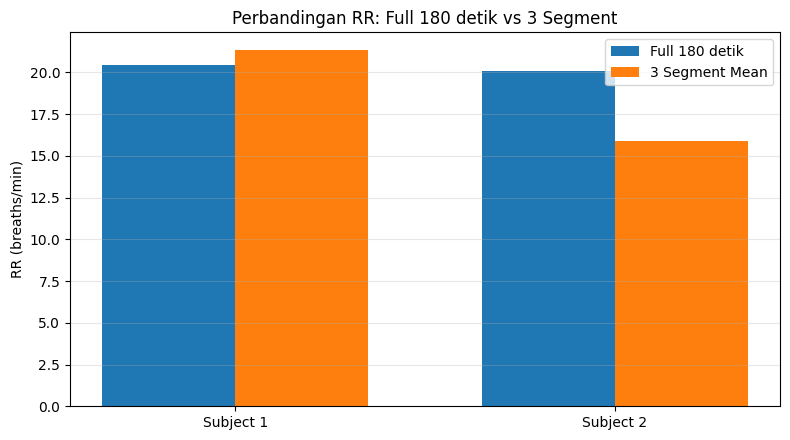

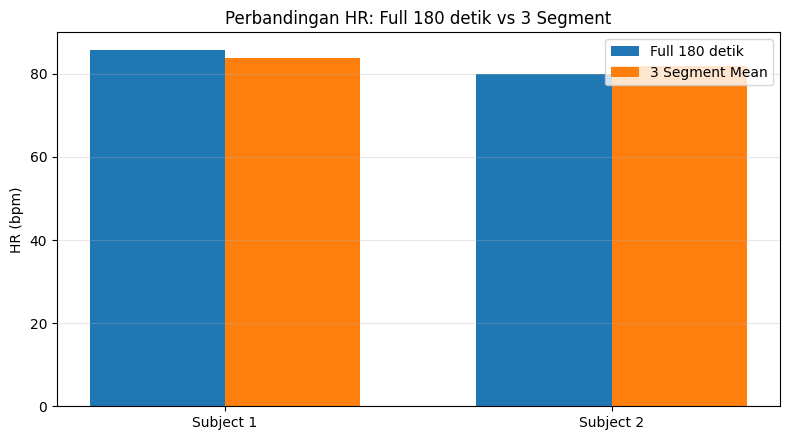

KESIMPULAN SEMENTARA
Ground truth belum diisi, jadi notebook belum bisa menentukan mana yang paling akurat.
Isi GROUND_TRUTH di cell pertama, lalu jalankan ulang cell hasil akhir ini.


In [54]:
# ============================================================
# 3) HASIL AKHIR: TABEL + GRAFIK FULL 180 DETIK VS 3 SEGMENT
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from IPython.display import display

FS_VITAL = 20.0
RR_BAND_HZ = (0.10, 0.50)
HR_BAND_HZ = (0.80, 2.00)
N_SEGMENTS = 3


def split_segments(x, n_segments=3):
    x = np.asarray(x, dtype=float)
    indices = np.array_split(np.arange(len(x)), n_segments)
    segments = []
    for i, idx in enumerate(indices, 1):
        if len(idx) == 0:
            continue
        start, end = int(idx[0]), int(idx[-1]) + 1
        segments.append((i, start, end, x[start:end]))
    return segments


def estimate_rr_frequency_domain(x, fs=FS_VITAL, rr_band_hz=RR_BAND_HZ):
    """RR frequency domain: FFT -> cari f_peak -> RR = f_peak*60."""
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    n = len(x)
    if n < 8:
        return np.nan, np.nan

    window = np.hanning(n)
    n_fft = int(2 ** np.ceil(np.log2(n * 4)))
    freqs = np.fft.rfftfreq(n_fft, d=1/fs)
    spectrum = np.abs(np.fft.rfft(x * window, n=n_fft))

    mask = (freqs >= rr_band_hz[0]) & (freqs <= rr_band_hz[1])
    freqs_band = freqs[mask]
    spectrum_band = spectrum[mask]
    if len(freqs_band) == 0:
        return np.nan, np.nan

    peak_idx = int(np.argmax(spectrum_band))
    f_peak = float(freqs_band[peak_idx])
    rr_value = float(f_peak * 60)
    return f_peak, rr_value


def estimate_hr_time_domain(x, fs=FS_VITAL, hr_band_hz=HR_BAND_HZ, prominence_factor=0.25):
    """HR time domain: peak detection -> median interval -> HR = 60/T_median."""
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    if len(x) < 8 or np.std(x) == 0:
        return np.nan, 0, np.nan

    min_distance_samples = max(1, int((1 / hr_band_hz[1]) * fs))
    prominence_value = prominence_factor * np.std(x)
    peaks, _ = find_peaks(x, distance=min_distance_samples, prominence=prominence_value)

    intervals_s = np.diff(peaks) / fs
    min_period_s = 1 / hr_band_hz[1]
    max_period_s = 1 / hr_band_hz[0]
    valid_intervals = intervals_s[(intervals_s >= min_period_s) & (intervals_s <= max_period_s)]

    if len(valid_intervals) == 0:
        return np.nan, len(peaks), np.nan

    T_median = float(np.median(valid_intervals))
    hr_value = float(60 / T_median)
    return hr_value, len(peaks), T_median


def err_metrics(est, gt):
    if gt is None or pd.isna(gt) or est is None or pd.isna(est):
        return np.nan, np.nan, np.nan
    abs_err = abs(float(est) - float(gt))
    err_pct = abs_err / float(gt) * 100 if float(gt) != 0 else np.nan
    acc = 100 - err_pct if not pd.isna(err_pct) else np.nan
    return abs_err, err_pct, acc


def gt_value(subject, param):
    try:
        return GROUND_TRUTH.get(subject, {}).get(param, None)
    except Exception:
        return None

# ------------------------------------------------------------
# Hitung perbandingan
# ------------------------------------------------------------
rows = []
segment_rows = []

for subject in sorted(filter_data.keys()):
    # RR: frequency domain
    phi_rr = np.asarray(filter_data[subject]["phi_rr"], dtype=float)
    gt_rr = gt_value(subject, "RR")

    f_full, rr_full = estimate_rr_frequency_domain(phi_rr)
    e_full, ep_full, a_full = err_metrics(rr_full, gt_rr)

    rr_seg_values = []
    rr_seg_freqs = []
    for seg_id, start, end, x_seg in split_segments(phi_rr, N_SEGMENTS):
        f_seg, rr_seg = estimate_rr_frequency_domain(x_seg)
        rr_seg_values.append(rr_seg)
        rr_seg_freqs.append(f_seg)
        segment_rows.append({
            "Subject": subject, "Parameter": "RR", "Segment": seg_id,
            "Estimasi Segment": rr_seg, "f_peak Segment (Hz)": f_seg
        })

    rr_3seg = float(np.nanmean(rr_seg_values))
    f_3seg = float(np.nanmean(rr_seg_freqs))
    e_3seg, ep_3seg, a_3seg = err_metrics(rr_3seg, gt_rr)

    rows.append({
        "Subject": subject,
        "Parameter": "RR",
        "Full 180 detik": rr_full,
        "3 Segment Mean": rr_3seg,
        "Ground Truth": gt_rr,
        "Error Full": e_full,
        "Error 3Seg": e_3seg,
        "Accuracy Full (%)": a_full,
        "Accuracy 3Seg (%)": a_3seg,
        "f_peak Full (Hz)": f_full,
        "f_peak 3Seg Mean (Hz)": f_3seg,
    })

    # HR: time domain
    phi_hr = np.asarray(filter_data[subject]["phi_hr"], dtype=float)
    gt_hr = gt_value(subject, "HR")

    hr_full, peak_full, T_full = estimate_hr_time_domain(phi_hr)
    e_full, ep_full, a_full = err_metrics(hr_full, gt_hr)

    hr_seg_values = []
    for seg_id, start, end, x_seg in split_segments(phi_hr, N_SEGMENTS):
        hr_seg, peaks_seg, T_seg = estimate_hr_time_domain(x_seg)
        hr_seg_values.append(hr_seg)
        segment_rows.append({
            "Subject": subject, "Parameter": "HR", "Segment": seg_id,
            "Estimasi Segment": hr_seg, "Jumlah Peak": peaks_seg,
            "Median Period Segment (s)": T_seg
        })

    hr_3seg = float(np.nanmean(hr_seg_values))
    e_3seg, ep_3seg, a_3seg = err_metrics(hr_3seg, gt_hr)

    rows.append({
        "Subject": subject,
        "Parameter": "HR",
        "Full 180 detik": hr_full,
        "3 Segment Mean": hr_3seg,
        "Ground Truth": gt_hr,
        "Error Full": e_full,
        "Error 3Seg": e_3seg,
        "Accuracy Full (%)": a_full,
        "Accuracy 3Seg (%)": a_3seg,
        "Jumlah Peak Full": peak_full,
        "Median Period Full (s)": T_full,
    })

compare_final_df = pd.DataFrame(rows)
segment_detail_df = pd.DataFrame(segment_rows)

# Tentukan metode yang lebih dekat ke ground truth jika GT tersedia.
def choose_best(row):
    if pd.isna(row["Error Full"]) or pd.isna(row["Error 3Seg"]):
        return "Isi ground truth dulu"
    if row["Error Full"] < row["Error 3Seg"]:
        return "Full 180 detik"
    if row["Error 3Seg"] < row["Error Full"]:
        return "3 Segment Mean"
    return "Sama"

compare_final_df["Metode Lebih Dekat"] = compare_final_df.apply(choose_best, axis=1)

# Tabel ringkas saja.
display_cols = [
    "Subject", "Parameter", "Full 180 detik", "3 Segment Mean", "Ground Truth",
    "Error Full", "Error 3Seg", "Accuracy Full (%)", "Accuracy 3Seg (%)", "Metode Lebih Dekat"
]
final_display = compare_final_df[display_cols].copy()
for col in final_display.columns:
    if col not in ["Subject", "Parameter", "Metode Lebih Dekat"]:
        final_display[col] = pd.to_numeric(final_display[col], errors="coerce").round(2)

print("TABEL AKHIR PERBANDINGAN FULL 180 DETIK VS 3 SEGMENT")
display(final_display)

# ------------------------------------------------------------
# Grafik akhir: RR dan HR saja
# ------------------------------------------------------------
def plot_comparison(param):
    dfp = compare_final_df[compare_final_df["Parameter"] == param].copy()
    labels = dfp["Subject"].tolist()
    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(8, 4.5))
    plt.bar(x - width/2, dfp["Full 180 detik"], width, label="Full 180 detik")
    plt.bar(x + width/2, dfp["3 Segment Mean"], width, label="3 Segment Mean")

    # Tampilkan ground truth sebagai titik jika diisi.
    gt = pd.to_numeric(dfp["Ground Truth"], errors="coerce")
    if gt.notna().any():
        plt.scatter(x, gt, marker="x", s=90, label="Ground Truth")

    unit = "breaths/min" if param == "RR" else "bpm"
    plt.title(f"Perbandingan {param}: Full 180 detik vs 3 Segment")
    plt.ylabel(f"{param} ({unit})")
    plt.xticks(x, labels)
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_comparison("RR")
plot_comparison("HR")

# ------------------------------------------------------------
# Kesimpulan otomatis jika ground truth sudah diisi
# ------------------------------------------------------------
print("KESIMPULAN SEMENTARA")
if compare_final_df["Ground Truth"].isna().all():
    print("Ground truth belum diisi, jadi notebook belum bisa menentukan mana yang paling akurat.")
    print("Isi GROUND_TRUTH di cell pertama, lalu jalankan ulang cell hasil akhir ini.")
else:
    for param in ["RR", "HR"]:
        dfp = compare_final_df[(compare_final_df["Parameter"] == param) & compare_final_df["Ground Truth"].notna()]
        if dfp.empty:
            continue
        mean_err_full = dfp["Error Full"].mean()
        mean_err_seg = dfp["Error 3Seg"].mean()
        if mean_err_full < mean_err_seg:
            print(f"Untuk {param}, Full 180 detik lebih dekat ke ground truth. MAE = {mean_err_full:.2f}.")
        elif mean_err_seg < mean_err_full:
            print(f"Untuk {param}, 3 Segment Mean lebih dekat ke ground truth. MAE = {mean_err_seg:.2f}.")
        else:
            print(f"Untuk {param}, Full 180 detik dan 3 Segment Mean memiliki error rata-rata yang sama.")
